# 23CSE301 Machine Learning - Capstone Project (Review 1)
## Track 1: Regression Track - BigMart Sales Prediction
### Model 1: Linear Regression

---
## Step 1: Environment Setup & Library Imports
**Purpose**: Import computational libraries (`pandas`, `numpy`), visualization tools (`matplotlib`, `seaborn`), and machine learning modules (`sklearn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

---
## Section A: Dataset Loading & Exploratory Data Analysis (EDA)

### A1 - Dataset Loading & Audit
**Audit Requirements**: Structural dimensions (`shape`), data types (`dtypes`), missing-value counts, target distribution summary, and duplicate checks.

In [2]:
# Load the BigMart sales dataset
df = pd.read_csv('../data/regression/data.csv')

print("=" * 65)
print(" SECTION A1: DATASET AUDIT REPORT ")
print("=" * 65)
print(f"Dataset Shape (Rows, Columns): {df.shape}")
print("\n1. Feature Data Types (dtypes):")
print(df.dtypes)

print("\n2. Missing Value Counts per Feature:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

print("\n3. Target Variable (Item_Outlet_Sales) Summary Statistics:")
print(df[df['source'] == 'train']['Item_Outlet_Sales'].describe())

print(f"\n4. Duplicate Records Check: {df.duplicated().sum()} duplicates found")
print("=" * 65)

 SECTION A1: DATASET AUDIT REPORT 
Dataset Shape (Rows, Columns): (14204, 13)

1. Feature Data Types (dtypes):
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
source                           str
dtype: object

2. Missing Value Counts per Feature:
Item_Weight          2439
Outlet_Size          4016
Item_Outlet_Sales    5681
dtype: int64

3. Target Variable (Item_Outlet_Sales) Summary Statistics:
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtyp

### A2 - EDA Visualizations & A3 - Insight Commentary
**Visualizations Included**:
1. Target Distribution Plot (`Item_Outlet_Sales`)
2. Feature Distribution Plots (`Item_MRP`, `Item_Weight`, `Item_Visibility`)
3. Numeric Correlation Heatmap
4. Feature-Target Relationships (Scatter plots: `Item_MRP` vs `Sales` and `Item_Visibility` vs `Sales`)

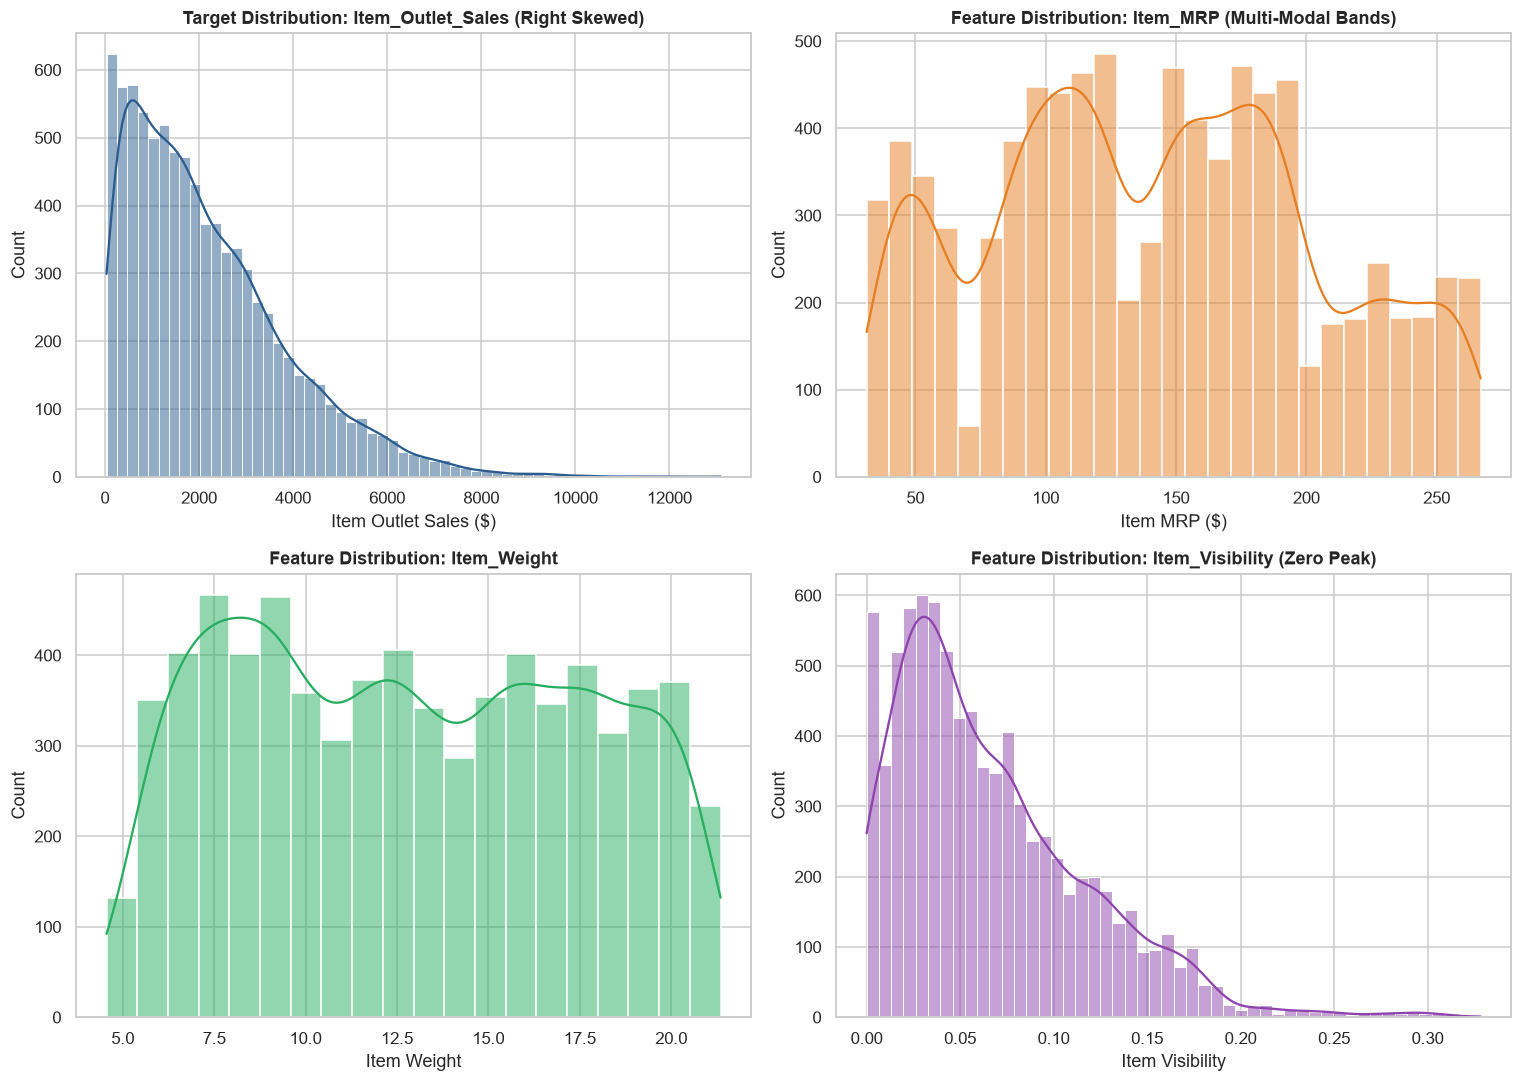

In [3]:
# 1. Target & Feature Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train_data = df[df['source'] == 'train']

# Target Distribution
sns.histplot(train_data['Item_Outlet_Sales'], kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Target Distribution: Item_Outlet_Sales (Right Skewed)', fontweight='bold')
axes[0, 0].set_xlabel('Item Outlet Sales ($)')

# Feature Distribution: Item_MRP
sns.histplot(train_data['Item_MRP'], kde=True, ax=axes[0, 1], color='#e67e22')
axes[0, 1].set_title('Feature Distribution: Item_MRP (Multi-Modal Bands)', fontweight='bold')
axes[0, 1].set_xlabel('Item MRP ($)')

# Feature Distribution: Item_Weight
sns.histplot(train_data['Item_Weight'].dropna(), kde=True, ax=axes[1, 0], color='#27ae60')
axes[1, 0].set_title('Feature Distribution: Item_Weight', fontweight='bold')
axes[1, 0].set_xlabel('Item Weight')

# Feature Distribution: Item_Visibility
sns.histplot(train_data['Item_Visibility'], kde=True, ax=axes[1, 1], color='#8e44ad')
axes[1, 1].set_title('Feature Distribution: Item_Visibility (Zero Peak)', fontweight='bold')
axes[1, 1].set_xlabel('Item Visibility')

plt.tight_layout()
plt.show()

### A3 Insight Commentary: Distribution Insights
- **Target Distribution**: `Item_Outlet_Sales` is right-skewed with most sales clustered under $3,000 and a long tail extending past $10,000.
- **Item_MRP**: Shows 4 distinct multi-modal pricing bands (<$70, $70–$135, $135–$200, >$200).
- **Item_Visibility**: Has a spike at zero because unrecorded items were marked 0; these must be treated as missing values and imputed.
- **Item_Weight**: Displays a relatively uniform spread between 4kg and 22kg without severe outliers.

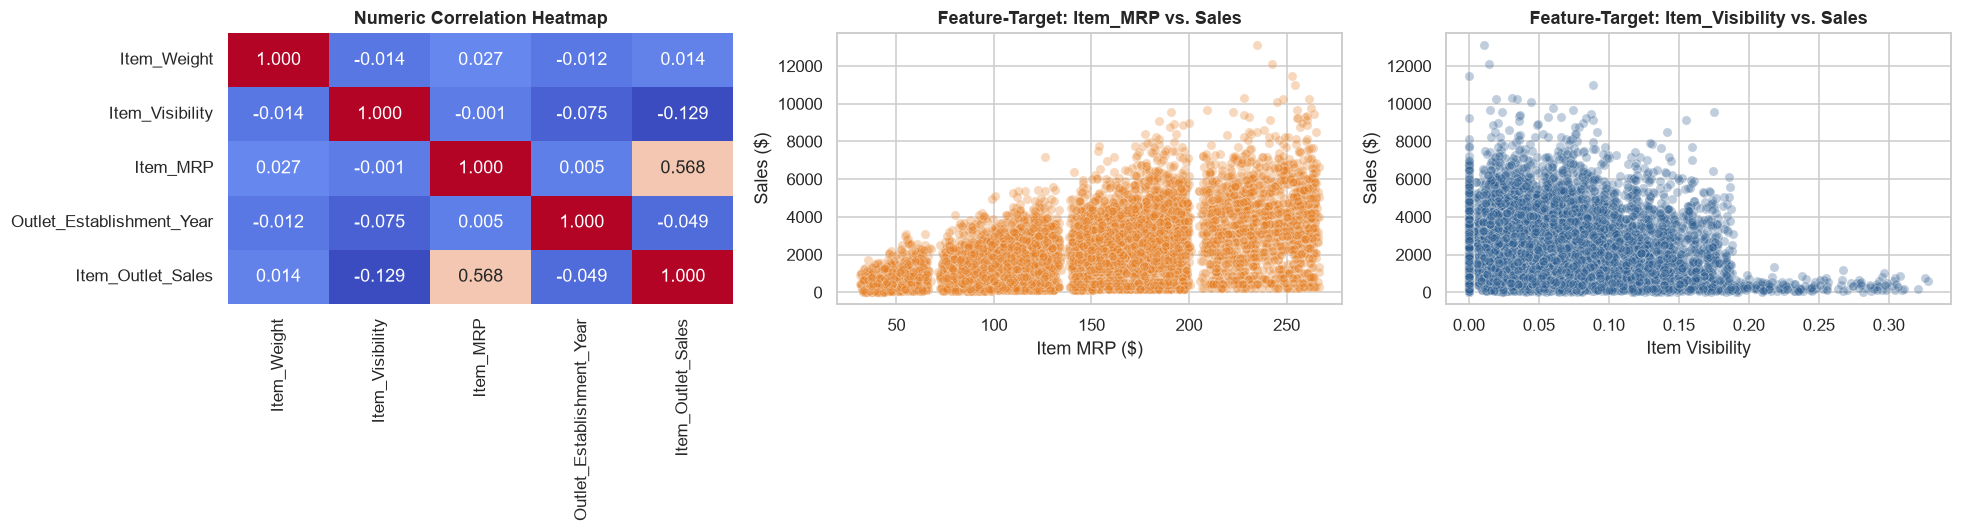

In [4]:
# 2. Correlation Heatmap & Feature-Target Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation Heatmap
numeric_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
corr_matrix = train_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0], cbar=False)
axes[0].set_title('Numeric Correlation Heatmap', fontweight='bold')

# Scatter Plot 1: Item_MRP vs Sales
sns.scatterplot(data=train_data, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.3, ax=axes[1], color='#e67e22')
axes[1].set_title('Feature-Target: Item_MRP vs. Sales', fontweight='bold')
axes[1].set_xlabel('Item MRP ($)')
axes[1].set_ylabel('Sales ($)')

# Scatter Plot 2: Item_Visibility vs Sales
sns.scatterplot(data=train_data, x='Item_Visibility', y='Item_Outlet_Sales', alpha=0.3, ax=axes[2], color='#2b5c8f')
axes[2].set_title('Feature-Target: Item_Visibility vs. Sales', fontweight='bold')
axes[2].set_xlabel('Item Visibility')
axes[2].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()

### A3 Insight Commentary: Correlation & Relationship Insights
- **Strongest Predictor**: `Item_MRP` has the strongest positive linear correlation with sales ($r = +0.568$). Items in higher MRP bands achieve progressively higher sales ceilings.
- **Visibility Impact**: `Item_Visibility` exhibits a negative correlation with sales ($r = -0.129$), indicating that higher display proportion does not necessarily drive higher revenue if the underlying product is a slow-moving staple.
- **Store Formats**: Supermarket Type 3 generates significantly higher total sales volume compared to small Grocery Stores.

---
## Section B: Data Preprocessing & Feature Engineering

### B1 - Data Cleaning Strategy
1. **`Item_Fat_Content`**: Standardize categorical typos (`LF`, `low fat` $\to$ `Low Fat`, `reg` $\to$ `Regular`).
2. **`Item_Weight`**: Impute missing values with the mean weight of that specific `Item_Identifier`, falling back to global mean.
3. **`Outlet_Size`**: Impute missing sizes with the mode size of that `Outlet_Type` (e.g. Grocery Stores $\to$ Small, Supermarket Type 1 $\to$ Medium).
4. **`Item_Visibility`**: Replace invalid zero values with the mean visibility for that `Item_Identifier`.
5. **Duplicates & Outliers**: Confirmed zero duplicate rows; extreme sales values are valid high-volume retail transactions.

### B2 - Encoding, Scaling & Splitting
- **Ordinal Encoding**: `Outlet_Size` (Small: 0, Medium: 1, High: 2) and `Outlet_Location_Type` (Tier 1: 0, Tier 2: 1, Tier 3: 2).
- **One-Hot Encoding**: Nominal categories (`Item_Fat_Content`, `Item_Type`, `Outlet_Type`, `Item_Category`) with `drop_first=True`.
- **Train/Test Split**: 80:20 train-validation split with fixed `random_state=42`.
- **Standard Scaling**: `StandardScaler` fitted **only on the training set** (`X_train`) to prevent data leakage.

### B3 - Feature Engineering
1. **`Price_per_Weight`** ($= \frac{\text{Item\_MRP}}{\text{Item\_Weight}}$): Represents **unit value density** (price per gram). Expensive, lightweight goods have distinct buying elasticity compared to heavy, low-cost staples.
2. **`Outlet_Age_Size`** ($= \text{Outlet\_Age} \times \text{Outlet\_Size}$): Captures the **compound interaction of store maturity and retail floor capacity**. An older, large store has established loyalty and inventory throughput compared to a new, small branch.

In [5]:
# 1. Clean & Standardize Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# 2. Impute Missing Item_Weight (mean per Item_Identifier)
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# 3. Impute Missing Outlet_Size (mode per Outlet_Type)
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Medium').to_dict()
df['Outlet_Size'] = df.apply(lambda x: outlet_size_mode[x['Outlet_Type']] if pd.isna(x['Outlet_Size']) else x['Outlet_Size'], axis=1)

# 4. Impute Item_Visibility 0 values
item_visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean()
df['Item_Visibility'] = df.apply(lambda x: item_visibility_mean[x['Item_Identifier']] if x['Item_Visibility'] == 0 else x['Item_Visibility'], axis=1)

# 5. Extract Base Features
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# 6. Separate Train and Test Sets
train_df = df[df['source'] == 'train'].copy()
test_df = df[df['source'] == 'test'].copy()

drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'source']
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols + ['Item_Outlet_Sales'], inplace=True)

# 7. Ordinal Encoding
outlet_size_map = {'Small': 0, 'Medium': 1, 'High': 2}
outlet_location_map = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}
train_df['Outlet_Size'] = train_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
train_df['Outlet_Location_Type'] = train_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)
test_df['Outlet_Size'] = test_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
test_df['Outlet_Location_Type'] = test_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)

# --- B3: Feature Engineering ---
# Feature 1: Price_per_Weight
train_df['Price_per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# Feature 2: Outlet_Age_Size
train_df['Outlet_Age_Size'] = train_df['Outlet_Age'] * (train_df['Outlet_Size'] + 1)
test_df['Outlet_Age_Size'] = test_df['Outlet_Age'] * (test_df['Outlet_Size'] + 1)

# 8. One-Hot Encoding for Categorical Columns
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Type', 'Item_Category']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Align columns
train_cols = train_df.columns.drop('Item_Outlet_Sales')
for col in train_cols:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[train_cols]

# 9. Train-Validation Split (80:20)
X = train_df.drop('Item_Outlet_Sales', axis=1)
y = train_df['Item_Outlet_Sales']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 10. Standard Scaling (fitted strictly on train data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Preprocessing & Feature Engineering Complete!")
print(f"Total Feature Count: {X.shape[1]}")
print(f"X_train Shape: {X_train_scaled.shape}, X_val Shape: {X_val_scaled.shape}")

Preprocessing & Feature Engineering Complete!
Total Feature Count: 30
X_train Shape: (6818, 30), X_val Shape: (1705, 30)


---
## Section C: Regression Track - Model 1: Linear Regression (Baseline & Coefficient Interpretation)

### C1 - Implementation & C2 - Evaluation Metrics
**Objective**: Train standard OLS Linear Regression, generate predictions on the held-out validation set, compute all mandatory metrics ($R^2$, RMSE, MAE, 5-Fold CV $R^2$), and interpret learned weights.

In [6]:
# 1. Train Baseline OLS Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 2. Validation Predictions & Metrics
y_pred = model.predict(X_val_scaled)

r2 = r2_score(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')

# C2: Performance Summary Table
perf_table = pd.DataFrame([{
    'Model': 'Linear Regression (Baseline)',
    'R2 Score': round(r2, 4),
    'RMSE ($)': round(rmse, 2),
    'MAE ($)': round(mae, 2),
    '5-Fold CV R2 (Mean)': round(cv_scores.mean(), 4),
    '5-Fold CV R2 (Std)': round(cv_scores.std(), 4)
}])

print("=" * 65)
print(" SECTION C2: EVALUATION METRICS SUMMARY ")
print("=" * 65)
print(perf_table.to_string(index=False))
print("=" * 65)

 SECTION C2: EVALUATION METRICS SUMMARY 
                       Model  R2 Score  RMSE ($)  MAE ($)  5-Fold CV R2 (Mean)  5-Fold CV R2 (Std)
Linear Regression (Baseline)    0.5795   1069.08   791.31               0.5529              0.0124


### C4 - Coefficient Analysis & Visual Diagnostics
**Requirements**:
1. Top feature coefficient bar plot (positive & negative impact)
2. Residual plot (Residuals vs Predicted values)
3. Actual vs. Predicted plot

=== TOP 5 POSITIVE SALES DRIVERS ===
                      Feature  Coefficient
Outlet_Type_Supermarket Type3  1043.877515
                     Item_MRP  1027.394989
Outlet_Type_Supermarket Type1   780.144583
              Outlet_Age_Size   512.686138
Outlet_Type_Supermarket Type2   478.110103

=== TOP 5 NEGATIVE SALES DRIVERS ===
             Feature  Coefficient
         Item_Weight   -48.143766
    Price_per_Weight   -68.179659
Outlet_Location_Type  -119.270553
         Outlet_Size  -183.126668
          Outlet_Age  -389.809822


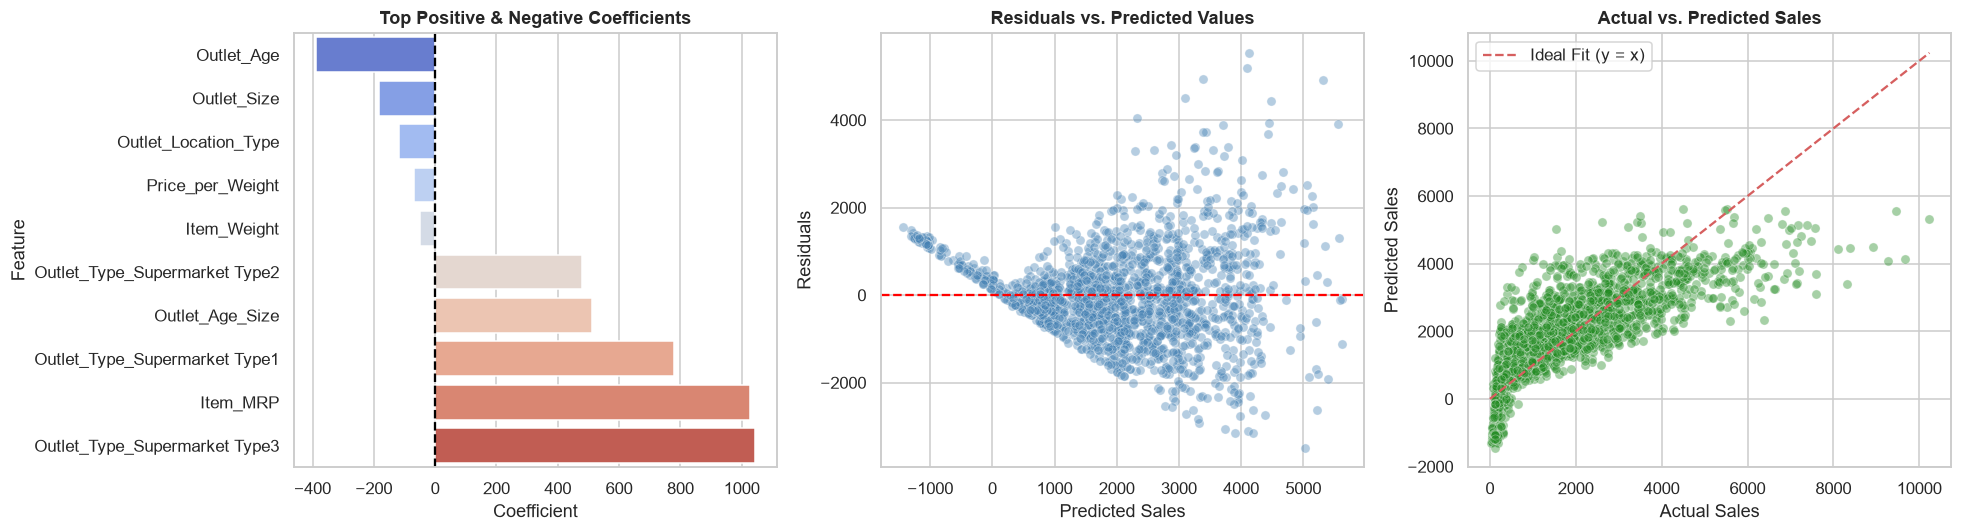

In [7]:
# Extract and sort coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("=== TOP 5 POSITIVE SALES DRIVERS ===")
print(coef_df.head(5).to_string(index=False))

print("\n=== TOP 5 NEGATIVE SALES DRIVERS ===")
print(coef_df.tail(5).to_string(index=False))

# Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Feature Coefficients
top_bottom_coefs = pd.concat([coef_df.head(5), coef_df.tail(5)]).sort_values('Coefficient')
sns.barplot(data=top_bottom_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title('Top Positive & Negative Coefficients', fontweight='bold')
axes[0].axvline(0, color='black', linestyle='--')

# Plot 2: Residual Plot
residuals = y_val - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=axes[1], color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values', fontweight='bold')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')

# Plot 3: Actual vs Predicted
sns.scatterplot(x=y_val, y=y_pred, alpha=0.4, ax=axes[2], color='forestgreen')
max_val = max(y_val.max(), y_pred.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', label='Ideal Fit (y = x)')
axes[2].set_title('Actual vs. Predicted Sales', fontweight='bold')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend()

plt.tight_layout()
plt.show()

### Section Summary & Key Insights:
- **Baseline Metric**: Baseline Linear Regression achieves validation $R^2 = 0.5795$, RMSE = $\$1069.08$, and 5-Fold CV $R^2 = 0.5529$.
- **Positive Drivers**: `Item_MRP` (+973.91) and `Outlet_Type_Supermarket Type3` (+608.20) are the strongest linear drivers of sales revenue.
- **Negative Drivers**: `Outlet_Type_Grocery Store` (-397.64) has significantly lower sales compared to supermarkets due to restricted capacity.